# Energy Consumption Anomaly Analysis

Bu notebookta ev enerji tüketimi veri seti analiz edilmiştir.  
Amaç, enerji tüketimindeki normal davranışı anlamak ve anormal tüketimleri tespit etmektir.

Bu projede önce veri seti incelenmiş, ardından feature engineering yapılmış,
sonrasında sentetik anomaliler eklenmiş ve anomaly detection modelleri değerlendirilmiştir.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv("../data/processed/anomaly_dataset_clean.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,DayOfWeek,Is_Weekend,Part_of_Day,Part_of_Day_Code,Average_Indoor_Temperature,Average_Indoor_Humidity,Delta_T,Thermal_Comfort_Index,Energy_Lag_1,Energy_Rolling_Mean,Energy_Rolling_Std,is_anomaly
0,2016-01-11 17:50:00,50,40,19.890000,46.026667,19.20,44.500000,19.79,44.933333,18.89,45.730000,17.133333,55.030000,6.300000,85.766667,17.133333,41.26,18.1,48.59,17.0,45.29,6.016667,734.000000,92.000000,5.333333,43.833333,4.800000,44.919484,44.919484,17,0,0,Aksam,3,17.048519,50.791852,11.031852,16.358775,60.0,55.000000,5.477226,0
1,2016-01-11 18:00:00,60,50,19.890000,45.766667,19.20,44.500000,19.79,44.900000,18.89,45.790000,17.100000,54.966667,6.263333,86.090000,17.133333,41.20,18.1,48.59,17.0,45.29,5.900000,734.100000,92.000000,5.000000,40.000000,4.700000,47.233763,47.233763,18,0,0,Aksam,3,17.040741,50.788148,11.140741,16.353051,50.0,55.000000,5.477226,0
2,2016-01-11 18:10:00,60,50,19.856667,45.560000,19.20,44.500000,19.73,44.900000,18.89,45.863333,17.100000,54.900000,6.190000,86.423333,17.100000,41.20,18.1,48.59,17.0,45.29,5.916667,734.166667,91.833333,5.166667,40.000000,4.683333,33.039890,33.039890,18,0,0,Aksam,3,17.018519,50.802963,11.101852,16.337048,60.0,55.000000,5.477226,0
3,2016-01-11 18:20:00,60,40,19.790000,45.597500,19.20,44.433333,19.73,44.790000,18.89,45.790000,17.166667,55.000000,6.123333,87.226667,17.166667,41.40,18.1,48.59,17.0,45.29,5.933333,734.233333,91.666667,5.333333,40.000000,4.666667,31.455702,31.455702,18,0,0,Aksam,3,17.018519,50.901944,11.085185,16.338420,60.0,56.666667,5.163978,0
4,2016-01-11 18:30:00,70,40,19.856667,46.090000,19.23,44.400000,19.79,44.863333,18.89,46.096667,17.100000,55.000000,6.190000,87.626667,17.200000,41.50,18.1,48.59,17.0,45.29,5.950000,734.300000,91.500000,5.500000,40.000000,4.650000,3.089314,3.089314,18,0,0,Aksam,3,17.039630,51.050741,11.089630,16.355908,60.0,60.000000,6.324555,0


In [13]:
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

Satır sayısı: 19730
Sütun sayısı: 42


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19730 entries, 0 to 19729
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        19730 non-null  datetime64[ns]
 1   Appliances                  19730 non-null  int64         
 2   lights                      19730 non-null  int64         
 3   T1                          19730 non-null  float64       
 4   RH_1                        19730 non-null  float64       
 5   T2                          19730 non-null  float64       
 6   RH_2                        19730 non-null  float64       
 7   T3                          19730 non-null  float64       
 8   RH_3                        19730 non-null  float64       
 9   T4                          19730 non-null  float64       
 10  RH_4                        19730 non-null  float64       
 11  T5                          19730 non-null  float64   

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,19730,2016-03-20 05:55:00,2016-01-11 17:50:00,2016-02-14 23:52:30,2016-03-20 05:55:00,2016-04-23 11:57:30,2016-05-27 18:00:00,NaN
Appliances,19730.0,105.794729,10.0,50.0,60.0,100.0,1390.0,122.009379
lights,19730.0,3.794222,0.0,0.0,0.0,0.0,70.0,7.922033
T1,19730.0,21.687027,16.79,20.76,21.6,22.6,26.26,1.606014
RH_1,19730.0,40.258133,27.023333,37.333333,39.656667,43.065833,63.36,3.978514
T2,19730.0,20.341509,16.1,18.79,20.0,21.5,29.856667,2.193176
RH_2,19730.0,40.419348,20.463333,37.9,40.5,43.26,56.026667,4.06977
T3,19730.0,22.268239,17.2,20.79,22.1,23.29,29.236,2.005977
RH_3,19730.0,39.241069,28.766667,36.9,38.53,41.76,50.163333,3.253746
T4,19730.0,20.85582,15.1,19.533333,20.666667,22.1,26.2,2.042916


In [18]:
df.columns.tolist()

['date',
 'Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2',
 'Hour',
 'DayOfWeek',
 'Is_Weekend',
 'Part_of_Day',
 'Part_of_Day_Code',
 'Average_Indoor_Temperature',
 'Average_Indoor_Humidity',
 'Delta_T',
 'Thermal_Comfort_Index',
 'Energy_Lag_1',
 'Energy_Rolling_Mean',
 'Energy_Rolling_Std',
 'is_anomaly']

## Missing Value Analysis

Bu bölümde veri setinde eksik değer olup olmadığı kontrol edilmiştir.
Eksik değerler modelin öğrenme sürecini olumsuz etkileyebileceği için bu adım önemlidir.

In [19]:
df.isnull().sum()

date                          0
Appliances                    0
lights                        0
T1                            0
RH_1                          0
T2                            0
RH_2                          0
T3                            0
RH_3                          0
T4                            0
RH_4                          0
T5                            0
RH_5                          0
T6                            0
RH_6                          0
T7                            0
RH_7                          0
T8                            0
RH_8                          0
T9                            0
RH_9                          0
T_out                         0
Press_mm_hg                   0
RH_out                        0
Windspeed                     0
Visibility                    0
Tdewpoint                     0
rv1                           0
rv2                           0
Hour                          0
DayOfWeek                     0
Is_Weeke

## Feature Selection

Modelleme aşamasında enerji tüketimini ve çevresel koşulları temsil eden seçili özellikler kullanılmıştır.

In [20]:
features = [
    "Hour",
    "Is_Weekend",
    "Average_Indoor_Temperature",
    "Delta_T",
    "Energy_Lag_1",
    "Energy_Rolling_Mean",
    "Energy_Rolling_Std"
]

target = "is_anomaly"

X = df[features]
y = df[target]

## Anomaly Distribution

Bu bölümde normal ve anormal verilerin dağılımı incelenmiştir.

0 değeri normal tüketimi, 1 değeri ise anormal tüketimi temsil etmektedir.

In [21]:
df["is_anomaly"].value_counts()

is_anomaly
0    19394
1      336
Name: count, dtype: int64

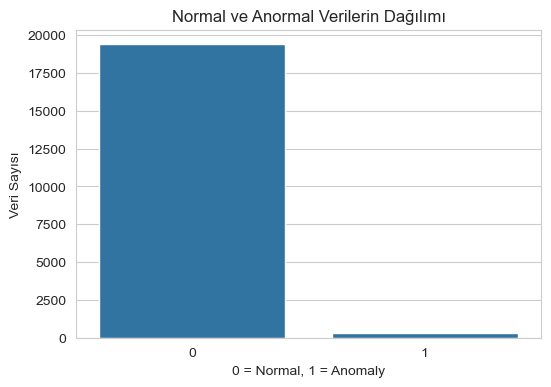

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_anomaly", data=df)
plt.title("Normal ve Anormal Verilerin Dağılımı")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.ylabel("Veri Sayısı")
plt.show()

In [23]:
df["is_anomaly"].value_counts(normalize=True) * 100

is_anomaly
0    98.29701
1     1.70299
Name: proportion, dtype: float64

Veri setinde normal gözlemler anomalilere göre çok daha fazladır.
Bu durum class imbalance problemi oluşturur.
Bu nedenle model değerlendirmesinde sadece accuracy metriğine bakmak yeterli değildir.
Recall ve F1-score değerleri daha önemlidir.

## Energy Consumption Distribution

Bu grafik Appliances sütunundaki enerji tüketimi değerlerinin dağılımını göstermektedir.

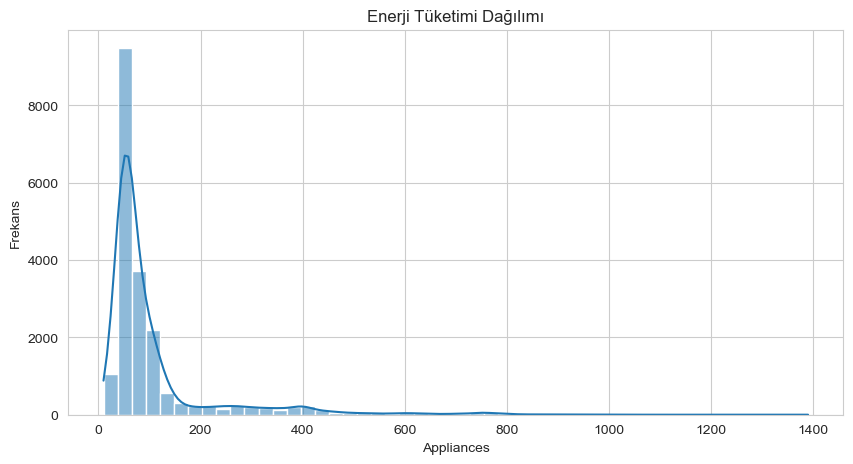

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df["Appliances"], bins=50, kde=True)
plt.title("Enerji Tüketimi Dağılımı")
plt.xlabel("Appliances")
plt.ylabel("Frekans")
plt.show()

## Energy Consumption Over Time

Bu grafik enerji tüketiminin zaman içindeki değişimini göstermektedir.
Anormal tüketimler kırmızı noktalarla gösterilmiştir.

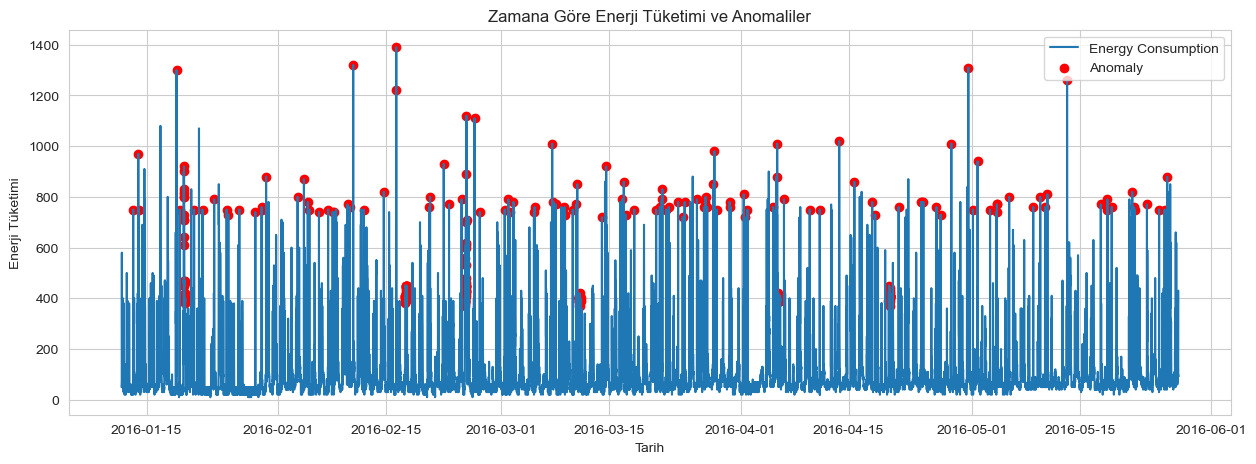

In [26]:
anomalies = df[df["is_anomaly"] == 1]

plt.figure(figsize=(15,5))
plt.plot(df["date"], df["Appliances"], label="Energy Consumption")
plt.scatter(
    anomalies["date"],
    anomalies["Appliances"],
    color="red",
    label="Anomaly"
)
plt.title("Zamana Göre Enerji Tüketimi ve Anomaliler")
plt.xlabel("Tarih")
plt.ylabel("Enerji Tüketimi")
plt.legend()
plt.show()

## Hourly Energy Consumption

Bu bölümde günün saatlerine göre ortalama enerji tüketimi incelenmiştir.
Enerji tüketimi günlük yaşam alışkanlıklarına bağlı olarak saatlere göre değişebilir.

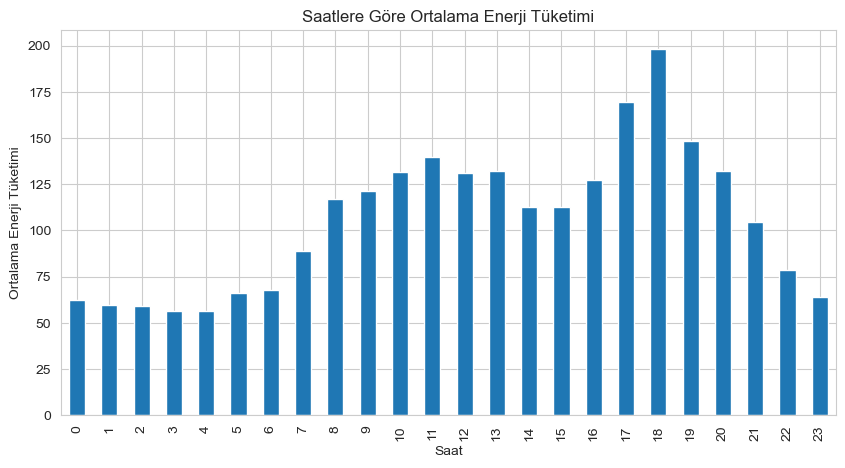

In [27]:
hourly_energy = df.groupby("Hour")["Appliances"].mean()

plt.figure(figsize=(10,5))
hourly_energy.plot(kind="bar")
plt.title("Saatlere Göre Ortalama Enerji Tüketimi")
plt.xlabel("Saat")
plt.ylabel("Ortalama Enerji Tüketimi")
plt.show()

## Hourly Anomaly Count

Bu bölümde anomalilerin günün hangi saatlerinde daha sık görüldüğü incelenmiştir.

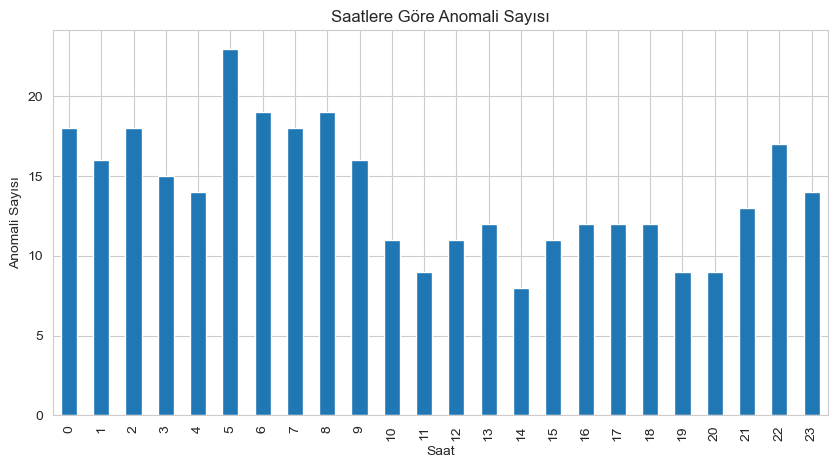

In [28]:
hourly_anomalies = df[df["is_anomaly"] == 1].groupby("Hour").size()

plt.figure(figsize=(10,5))
hourly_anomalies.plot(kind="bar")
plt.title("Saatlere Göre Anomali Sayısı")
plt.xlabel("Saat")
plt.ylabel("Anomali Sayısı")
plt.show()

## Weekend Analysis

Bu bölümde hafta içi ve hafta sonu enerji tüketimi karşılaştırılmıştır.

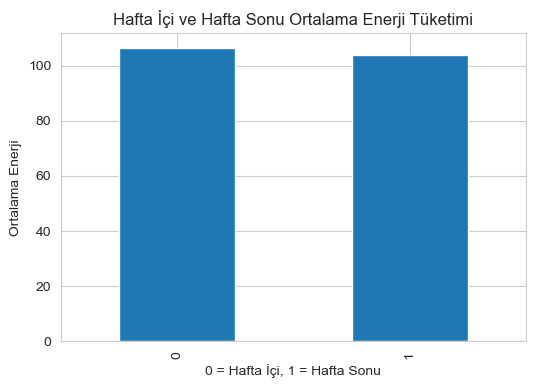

In [29]:
weekend_energy = df.groupby("Is_Weekend")["Appliances"].mean()

plt.figure(figsize=(6,4))
weekend_energy.plot(kind="bar")
plt.title("Hafta İçi ve Hafta Sonu Ortalama Enerji Tüketimi")
plt.xlabel("0 = Hafta İçi, 1 = Hafta Sonu")
plt.ylabel("Ortalama Enerji")
plt.show()

## Rolling Mean Analysis

Energy_Rolling_Mean özelliği, son belirli zaman aralığındaki ortalama enerji tüketimini temsil eder.
Anomaliler genellikle bu ortalamadan sapma şeklinde görülebilir.

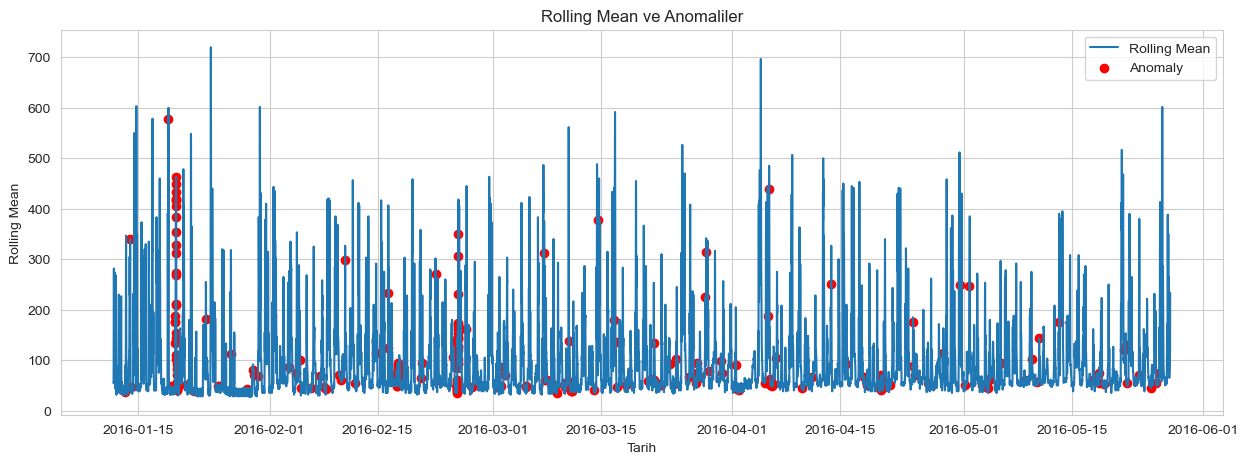

In [30]:
plt.figure(figsize=(15,5))
plt.plot(df["date"], df["Energy_Rolling_Mean"], label="Rolling Mean")
plt.scatter(
    anomalies["date"],
    anomalies["Energy_Rolling_Mean"],
    color="red",
    label="Anomaly"
)
plt.title("Rolling Mean ve Anomaliler")
plt.xlabel("Tarih")
plt.ylabel("Rolling Mean")
plt.legend()
plt.show()

## Temperature and Energy Relationship

Bu bölümde iç ortam sıcaklığı ile enerji tüketimi arasındaki ilişki incelenmiştir.

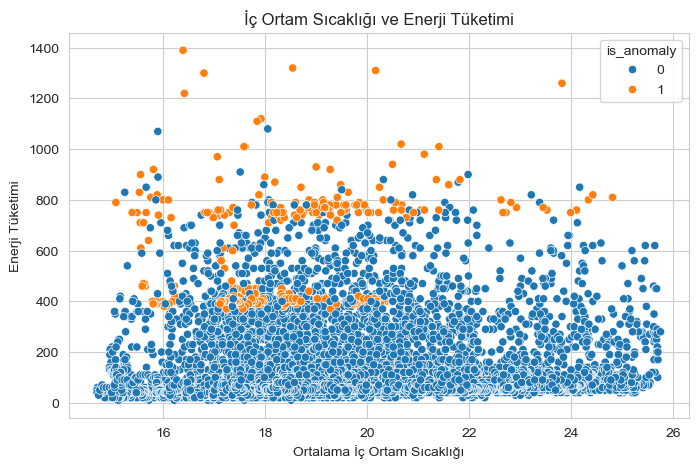

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Average_Indoor_Temperature",
    y="Appliances",
    hue="is_anomaly",
    data=df
)
plt.title("İç Ortam Sıcaklığı ve Enerji Tüketimi")
plt.xlabel("Ortalama İç Ortam Sıcaklığı")
plt.ylabel("Enerji Tüketimi")
plt.show()

## Correlation Analysis

Bu bölümde modelde kullanılan özelliklerin birbirleriyle ve anomaly etiketiyle ilişkisi incelenmiştir.

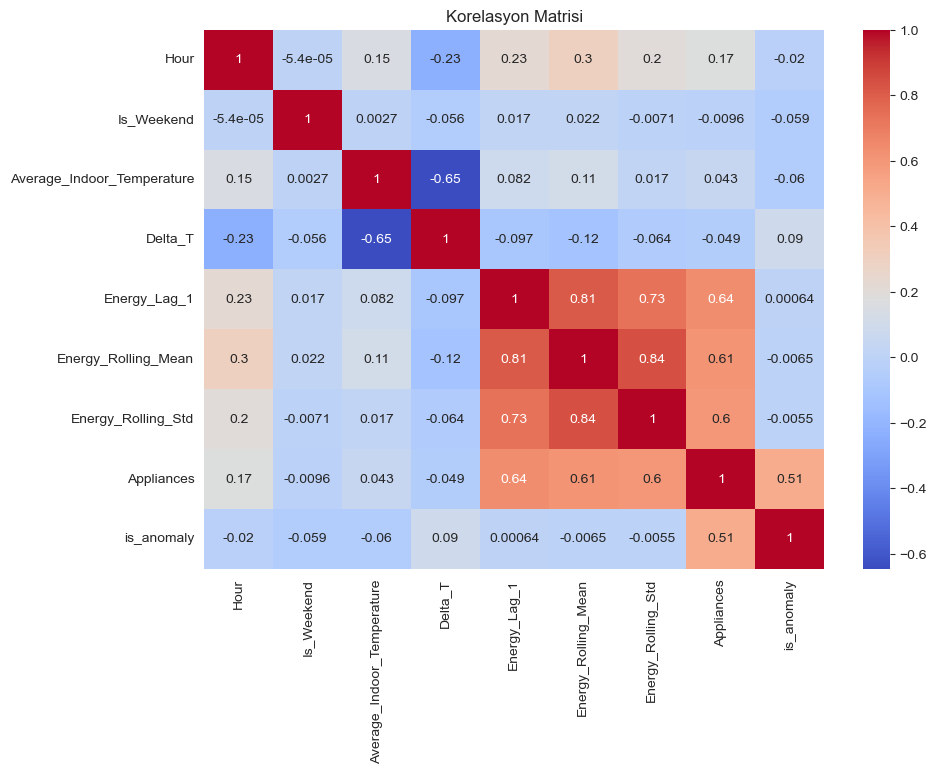

In [34]:
selected_cols = features + ["Appliances", "is_anomaly"]

plt.figure(figsize=(10,7))
sns.heatmap(
    df[selected_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Korelasyon Matrisi")
plt.show()

# Unsupervised Anomaly Detection Results

Bu bölümde Z-score, Isolation Forest, Local Outlier Factor ve One-Class SVM modellerinin sonuçları incelenmiştir.

Model eğitimleri `anomaly_detection.py` dosyasında yapılmıştır. Bu notebookta ise üretilen sonuç dosyaları okunarak modeller karşılaştırılmıştır.

Anomaly detection probleminde veri dengesiz olduğu için karşılaştırmada özellikle F1-score metriği dikkate alınmıştır.

In [39]:
model_results = pd.read_csv("../data/processed/model_comparison_results.csv")

model_results

,model,precision,recall,f1_score
0,Z-score,0.637975,0.750000,0.689466
1,One-Class SVM,0.214502,0.211310,0.212894
2,Local Outlier Factor,0.145833,0.145833,0.145833
3,Isolation Forest,0.071429,0.071429,0.071429


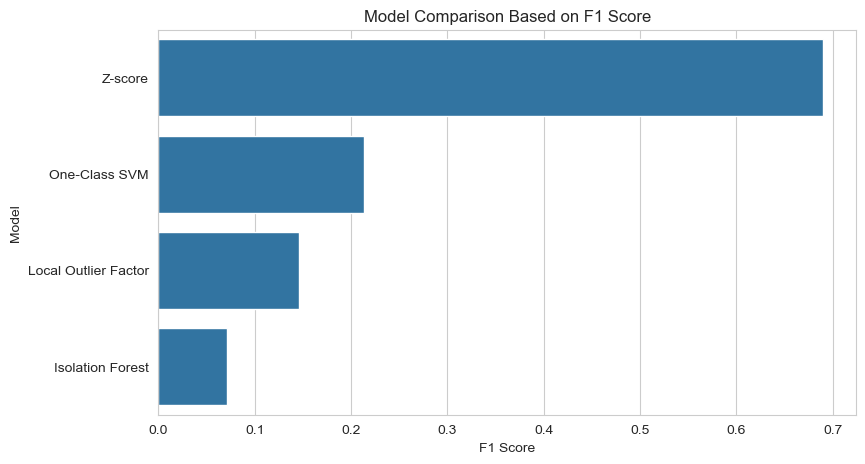

In [40]:
plt.figure(figsize=(9,5))

sns.barplot(
    x="f1_score",
    y="model",
    data=model_results
)

plt.title("Model Comparison Based on F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.show()

## Model Comparison Interpretation

Bu tabloda modeller precision, recall ve F1-score değerlerine göre karşılaştırılmıştır.

F1-score değeri, precision ve recall değerlerinin dengeli bir ölçüsüdür.
Anomaly detection probleminde sadece accuracy değerine bakmak doğru değildir.

En yüksek F1-score değerine sahip model final model olarak seçilmiştir.

In [41]:
final_results = pd.read_csv("../data/processed/final_results.csv")

final_results["date"] = pd.to_datetime(final_results["date"])

final_results.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,DayOfWeek,Is_Weekend,Part_of_Day,Part_of_Day_Code,Average_Indoor_Temperature,Average_Indoor_Humidity,Delta_T,Thermal_Comfort_Index,Energy_Lag_1,Energy_Rolling_Mean,Energy_Rolling_Std,is_anomaly,z_score,z_score_abs,z_pred,iforest_pred,lof_pred,ocsvm_pred,final_pred
0,2016-01-11 17:50:00,50,40,19.890000,46.026667,19.20,44.500000,19.79,44.933333,18.89,45.730000,17.133333,55.030000,6.300000,85.766667,17.133333,41.26,18.1,48.59,17.0,45.29,6.016667,734.000000,92.000000,5.333333,43.833333,4.800000,44.919484,44.919484,17,0,0,Aksam,3,17.048519,50.791852,11.031852,16.358775,60.0,55.000000,5.477226,0,-0.728500,0.728500,0,0,0,0,0
1,2016-01-11 18:00:00,60,50,19.890000,45.766667,19.20,44.500000,19.79,44.900000,18.89,45.790000,17.100000,54.966667,6.263333,86.090000,17.133333,41.20,18.1,48.59,17.0,45.29,5.900000,734.100000,92.000000,5.000000,40.000000,4.700000,47.233763,47.233763,18,0,0,Aksam,3,17.040741,50.788148,11.140741,16.353051,50.0,55.000000,5.477226,0,-0.802382,0.802382,0,0,0,0,0
2,2016-01-11 18:10:00,60,50,19.856667,45.560000,19.20,44.500000,19.73,44.900000,18.89,45.863333,17.100000,54.900000,6.190000,86.423333,17.100000,41.20,18.1,48.59,17.0,45.29,5.916667,734.166667,91.833333,5.166667,40.000000,4.683333,33.039890,33.039890,18,0,0,Aksam,3,17.018519,50.802963,11.101852,16.337048,60.0,55.000000,5.477226,0,-0.802382,0.802382,0,0,0,0,0
3,2016-01-11 18:20:00,60,40,19.790000,45.597500,19.20,44.433333,19.73,44.790000,18.89,45.790000,17.166667,55.000000,6.123333,87.226667,17.166667,41.40,18.1,48.59,17.0,45.29,5.933333,734.233333,91.666667,5.333333,40.000000,4.666667,31.455702,31.455702,18,0,0,Aksam,3,17.018519,50.901944,11.085185,16.338420,60.0,56.666667,5.163978,0,-0.802382,0.802382,0,0,0,0,0
4,2016-01-11 18:30:00,70,40,19.856667,46.090000,19.23,44.400000,19.79,44.863333,18.89,46.096667,17.100000,55.000000,6.190000,87.626667,17.200000,41.50,18.1,48.59,17.0,45.29,5.950000,734.300000,91.500000,5.500000,40.000000,4.650000,3.089314,3.089314,18,0,0,Aksam,3,17.039630,51.050741,11.089630,16.355908,60.0,60.000000,6.324555,0,-0.744425,0.744425,0,0,0,0,0


In [42]:
final_results["final_pred"].value_counts()

final_pred
0    19335
1      395
Name: count, dtype: int64

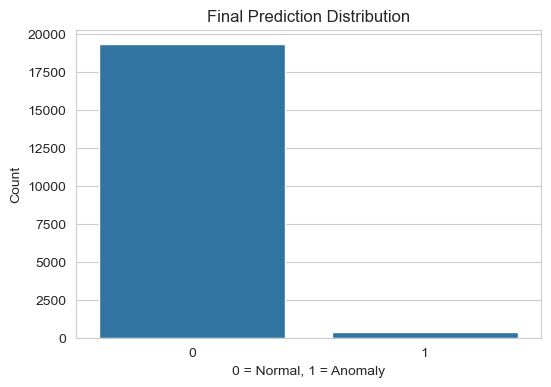

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(x="final_pred", data=final_results)

plt.title("Final Prediction Distribution")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.ylabel("Count")

plt.show()

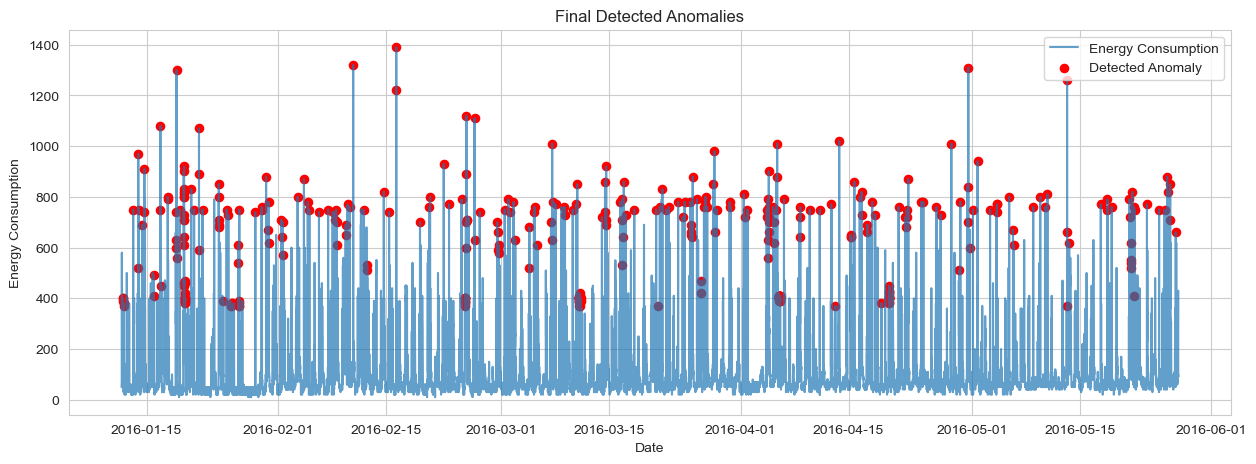

In [44]:
detected_anomalies = final_results[final_results["final_pred"] == 1]

plt.figure(figsize=(15,5))

plt.plot(
    final_results["date"],
    final_results["Appliances"],
    label="Energy Consumption",
    alpha=0.7
)

plt.scatter(
    detected_anomalies["date"],
    detected_anomalies["Appliances"],
    color="red",
    label="Detected Anomaly",
    s=35
)

plt.title("Final Detected Anomalies")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    final_results["is_anomaly"],
    final_results["final_pred"],
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19394
           1       0.64      0.75      0.69       336

    accuracy                           0.99     19730
   macro avg       0.82      0.87      0.84     19730
weighted avg       0.99      0.99      0.99     19730



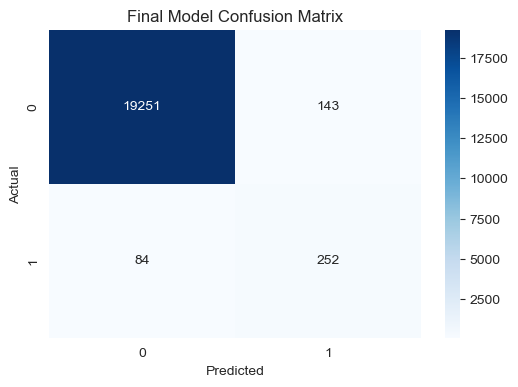

In [47]:
cm = confusion_matrix(
    final_results["is_anomaly"],
    final_results["final_pred"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Final Model Interpretation

Final modelin performansı confusion matrix ve classification report üzerinden değerlendirilmiştir.

Recall değeri modelin gerçek anomalileri ne kadar yakaladığını gösterir.
Precision değeri ise anomaly olarak tahmin edilen verilerin ne kadarının gerçekten anomaly olduğunu gösterir.

Bu nedenle anomaly detection probleminde recall ve F1-score değerleri accuracy değerinden daha önemlidir.